<a href="https://colab.research.google.com/github/Gus86git/SmartDispatch/blob/main/SE_%2B_Algoritmos_geneticos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Optimizador Genético con Validación Experta para Logística de Construcción**

Un sistema de inteligencia artificial que resuelve uno de los problemas más costosos en la logística de construcción: planificar diariamente qué materiales van en qué camión, por qué ruta, y en qué orden, garantizando al mismo tiempo que ninguna decisión viole reglas físicas, químicas o legales.

Problema Central: Un despachador humano tarda entre 3 y 5 horas armando hojas de ruta en Excel. Un error de peso provoca una multa de tránsito. Un error de compatibilidad química puede dañar materiales por valor de miles de dólares. Un retraso en la entrega detiene una obra completa.

La solución combina dos técnicas de IA complementarias:
Algoritmo Genético (AG): actúa como el 'músculo de optimización'. Explora millones de combinaciones posibles de rutas y asignaciones de pedidos para encontrar la de menor costo en distancia y cantidad de camiones.
Sistema Experto (SE): actúa como el 'cerebro de compliance'. Evalúa cada solución propuesta por el AG contra 30 reglas de negocio (compatibilidad química, límites de peso, ventanas horarias, certificaciones de proveedores) y penaliza las que las violan.

El resultado es una hoja de ruta generada en menos de 60 segundos que es simultáneamente óptima en costo y 100% válida según todas las restricciones del negocio.



## **Arquitectura del sistema**

**Instalación de Dependencias**

Instala las librerías necesarias para todo el proyecto:
- **deap**: implementación del Algoritmo Genético (selección, cruce, mutación, estadísticas de evolución)
- **experta**: motor de reglas para Sistemas Expertos basado en CLIPS (no se usa directamente en este notebook, pero queda disponible como alternativa)
- **folium**: mapas interactivos para el EDA geoespacial
- **pandas / numpy**: manipulación de datos y cálculo numérico
- **matplotlib / seaborn**: visualizaciones estáticas del EDA
- **scikit-learn**: utilidades generales de preprocesamiento (reservado para futuras extensiones)

> Nota: la línea `os.kill(os.getpid(), 9)` está comentada — solo se usaría si Colab necesita reiniciar el runtime después de instalar dependencias nuevas. No es necesaria en ejecuciones posteriores.

In [ ]:
# INSTALACIÓN DE DEPENDENCIAS

!pip install deap experta folium pandas numpy matplotlib seaborn scikit-learn -q

# Reiniciar el entorno automáticamente
#import os
#os.kill(os.getpid(), 9)

**Imports y Configuración del Entorno**

Importa todas las librerías y configura el sistema de **logging** en lugar de usar `print()` sueltos, simulando un entorno de producción real.

También fija las semillas aleatorias (`random.seed(42)`, `np.random.seed(42)`) para que los resultados sean **reproducibles**: cada vez que se ejecute el notebook desde cero, el dataset generado y la evolución del AG serán idénticos.

In [ ]:
# IMPORTS Y CONFIGURACIÓN

import random
import math
import logging
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import folium
import warnings
warnings.filterwarnings('ignore')

from deap import base, creator, tools, algorithms
from dataclasses import dataclass, field
from typing import List, Dict, Tuple, Optional
from IPython.display import display, HTML

# Logger de producción (no print() sueltos)
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s | %(levelname)s | %(message)s'
)
logger = logging.getLogger("SmartDispatch")

random.seed(42)
np.random.seed(42)
logger.info("Entorno inicializado correctamente.")

**Modelado del Dominio (Programación Orientada a Objetos)**

Define las clases que representan las entidades del negocio:

- **`Material`**: tipo, peso, volumen, si requiere clima controlado, si es peligroso.
- **`Pedido`**: un pedido concreto — qué material, a qué obra, en qué ventana horaria, si el proveedor está certificado.
- **`Camion`**: capacidad de peso/volumen, lista de pedidos asignados, y propiedades (`peso_total`, `volumen_total`) que se recalculan automáticamente.

También se define `MATERIALES_INCOMPATIBLES`: un conjunto de pares de materiales que **no pueden viajar juntos** en el mismo camión (ej. Cemento + Yeso → fraguado prematuro). Esta es la base del conocimiento químico que usará el Sistema Experto más adelante.

In [ ]:
# CLASES POO (DOMINIO DEL NEGOCIO)

# --- Constantes del dominio ---
MATERIALES_INCOMPATIBLES = {
    frozenset({"Cemento", "Yeso"}),
    frozenset({"Cemento", "Material Húmedo"}),
    frozenset({"Yeso", "Material Húmedo"}),
    frozenset({"Acero", "Ácido"}),
}

@dataclass
class Material:
    nombre: str
    peso_kg: float
    volumen_m3: float
    requiere_clima_controlado: bool = False
    es_peligroso: bool = False

@dataclass
class Pedido:
    id: str
    material: Material
    obra_destino: str
    coordenadas: Tuple[float, float]   # (lat, lon)
    ventana_inicio: int                # hora en minutos desde 00:00
    ventana_fin: int
    proveedor_certificado: bool = True

@dataclass
class Camion:
    id: str
    capacidad_peso_kg: float = 45000.0
    capacidad_volumen_m3: float = 60.0
    tiene_clima_controlado: bool = False
    velocidad_kmh: float = 60.0
    pedidos: List[Pedido] = field(default_factory=list)

    @property
    def peso_total(self) -> float:
        return sum(p.material.peso_kg for p in self.pedidos)

    @property
    def volumen_total(self) -> float:
        return sum(p.material.volumen_m3 for p in self.pedidos)

    def puede_agregar(self, pedido: Pedido) -> bool:
        return (
            self.peso_total + pedido.material.peso_kg <= self.capacidad_peso_kg and
            self.volumen_total + pedido.material.volumen_m3 <= self.capacidad_volumen_m3
        )

logger.info("Clases del dominio definidas: Material, Pedido, Camion.")

**Generación del Dataset Sintético**

Genera un dataset realista de **20 pedidos** distribuidos entre 20 obras ficticias alrededor del Corralón Central (coordenadas de Buenos Aires).

Cada pedido tiene:
- Un material aleatorio (Cemento, Acero, Yeso, Madera, Material Húmedo o Aditivo Químico) con peso y volumen variables.
- Una ventana horaria de 2 horas, comenzando a las 8:00, 9:00 o 10:00.
- Una probabilidad del 90% de tener proveedor certificado (10% sin certificar, simulando un caso real).

El resultado se vuelca en un DataFrame de pandas (`df`) que se usa tanto para el EDA como para alimentar el Algoritmo Genético.

In [ ]:
# DATASET SINTÉTICO REALISTA

CORRALON = {"nombre": "Corralón Central", "lat": -34.603722, "lon": -58.381592}

OBRAS = [
    {"nombre": f"Obra_{i}", "lat": -34.603722 + random.uniform(-0.15, 0.15),
     "lon": -58.381592 + random.uniform(-0.15, 0.15)}
    for i in range(1, 21)
]

TIPOS_MATERIALES = [
    {"nombre": "Cemento",          "peso_base": 1500, "vol_base": 1.2, "peligroso": False, "clima": False},
    {"nombre": "Acero",            "peso_base": 3000, "vol_base": 2.0, "peligroso": False, "clima": False},
    {"nombre": "Yeso",             "peso_base": 800,  "vol_base": 0.8, "peligroso": False, "clima": False},
    {"nombre": "Madera",           "peso_base": 1200, "vol_base": 3.0, "peligroso": False, "clima": False},
    {"nombre": "Material Húmedo",  "peso_base": 2000, "vol_base": 1.5, "peligroso": False, "clima": False},
    {"nombre": "Aditivo Químico",  "peso_base": 500,  "vol_base": 0.5, "peligroso": True,  "clima": True},
]

def generar_pedidos(n: int = 20) -> List[Pedido]:
    pedidos = []
    for i in range(n):
        obra = random.choice(OBRAS)
        mat_data = random.choice(TIPOS_MATERIALES)
        material = Material(
            nombre=mat_data["nombre"],
            peso_kg=mat_data["peso_base"] + random.uniform(-200, 200),
            volumen_m3=mat_data["vol_base"] + random.uniform(-0.2, 0.2),
            requiere_clima_controlado=mat_data["clima"],
            es_peligroso=mat_data["peligroso"],
        )
        inicio = random.choice([480, 540, 600])   # 8:00, 9:00 o 10:00
        pedidos.append(Pedido(
            id=f"P{i+1:02d}",
            material=material,
            obra_destino=obra["nombre"],
            coordenadas=(obra["lat"], obra["lon"]),
            ventana_inicio=inicio,
            ventana_fin=inicio + 120,
            proveedor_certificado=random.random() > 0.1,
        ))
    return pedidos

PEDIDOS = generar_pedidos(20)

# DataFrame para EDA
df = pd.DataFrame([{
    "ID": p.id,
    "Material": p.material.nombre,
    "Peso_kg": round(p.material.peso_kg, 1),
    "Volumen_m3": round(p.material.volumen_m3, 2),
    "Obra": p.obra_destino,
    "Ventana_Inicio": f"{p.ventana_inicio//60:02d}:{p.ventana_inicio%60:02d}",
    "Ventana_Fin": f"{p.ventana_fin//60:02d}:{p.ventana_fin%60:02d}",
    "Certificado": p.proveedor_certificado,
} for p in PEDIDOS])

logger.info(f"Dataset generado: {len(PEDIDOS)} pedidos.")
display(df.head(10))

,ID,Material,Peso_kg,Volumen_m3,Obra,Ventana_Inicio,Ventana_Fin,Certificado
0,P01,Cemento,1564.5,1.31,Obra_3,08:00,10:00,True
1,P02,Madera,1111.2,3.05,Obra_4,09:00,11:00,True
2,P03,Acero,3068.1,2.08,Obra_12,10:00,12:00,True
3,P04,Aditivo Químico,368.5,0.59,Obra_20,08:00,10:00,True
4,P05,Aditivo Químico,575.3,0.39,Obra_9,09:00,11:00,True
5,P06,Acero,3128.7,2.12,Obra_2,09:00,11:00,True
6,P07,Material Húmedo,2150.5,1.43,Obra_7,10:00,12:00,True
7,P08,Acero,2906.0,1.90,Obra_15,10:00,12:00,True
8,P09,Madera,1359.1,2.96,Obra_19,08:00,10:00,True
9,P10,Material Húmedo,1997.4,1.60,Obra_5,08:00,10:00,True


**Análisis Exploratorio de Datos (EDA)**

Genera tres visualizaciones que **justifican las reglas del Sistema Experto**:

1. **Barplot** de pedidos por tipo de material → muestra si hay concentración de materiales potencialmente incompatibles.
2. **Boxplot** de peso por material → muestra la variabilidad de pesos, justificando los límites de carga por camión.
3. **Pie chart** de certificaciones → muestra qué porcentaje de proveedores no cumple con la normativa ISO/FSC.

El gráfico se guarda como `eda_pedidos.png` para incluir en el informe final.

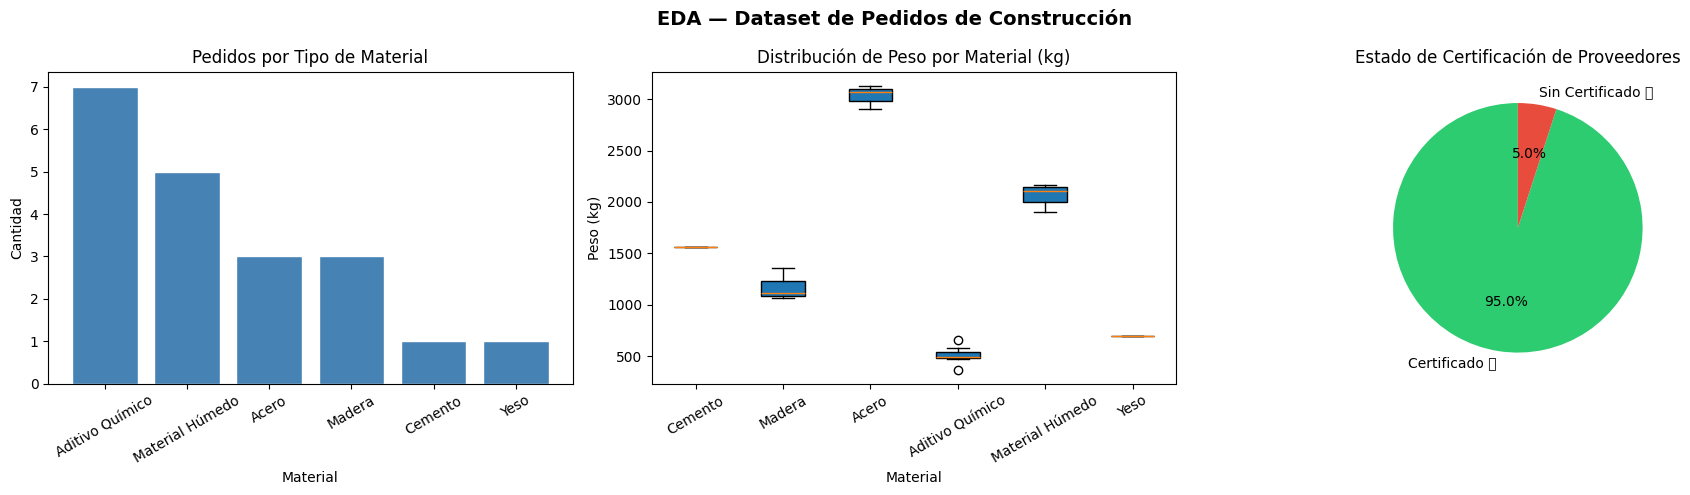

In [ ]:
# EDA — ANÁLISIS EXPLORATORIO

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("EDA — Dataset de Pedidos de Construcción", fontsize=14, fontweight="bold")

# 1. Distribución de materiales
conteo = df["Material"].value_counts()
axes[0].bar(conteo.index, conteo.values, color="steelblue", edgecolor="white")
axes[0].set_title("Pedidos por Tipo de Material")
axes[0].set_xlabel("Material")
axes[0].set_ylabel("Cantidad")
axes[0].tick_params(axis='x', rotation=30)

# 2. Boxplot de Peso por Material
materiales = df["Material"].unique()
datos_boxplot = [df[df["Material"] == m]["Peso_kg"].values for m in materiales]
axes[1].boxplot(datos_boxplot, labels=materiales, patch_artist=True)
axes[1].set_title("Distribución de Peso por Material (kg)")
axes[1].set_xlabel("Material")
axes[1].set_ylabel("Peso (kg)")
axes[1].tick_params(axis='x', rotation=30)

# 3. Certificaciones
cert_counts = df["Certificado"].value_counts()
axes[2].pie(cert_counts.values,
            labels=["Certificado ✅", "Sin Certificado ❌"],
            colors=["#2ecc71", "#e74c3c"],
            autopct="%1.1f%%", startangle=90)
axes[2].set_title("Estado de Certificación de Proveedores")

plt.tight_layout()
plt.savefig("eda_pedidos.png", dpi=150, bbox_inches="tight")
plt.show()
logger.info("EDA completado.")

**Mapa Geoespacial Interactivo**

Construye un mapa con **Folium** centrado en el Corralón Central. Cada pedido se representa como un círculo coloreado según el tipo de material, con un popup mostrando ID, material y peso.

Permite visualizar **clusters de obras cercanas** que el Algoritmo Genético debería agrupar en el mismo camión para minimizar distancia recorrida.

In [ ]:
# MAPA GEOSPACIAL

mapa = folium.Map(location=[CORRALON["lat"], CORRALON["lon"]], zoom_start=13)

# Corralón
folium.Marker(
    [CORRALON["lat"], CORRALON["lon"]],
    popup="🏭 Corralón Central",
    icon=folium.Icon(color="red", icon="home")
).add_to(mapa)

# Obras
colores = {"Cemento": "blue", "Acero": "gray", "Yeso": "orange",
           "Madera": "green", "Material Húmedo": "purple", "Aditivo Químico": "darkred"}

for p in PEDIDOS:
    folium.CircleMarker(
        location=p.coordenadas,
        radius=8,
        color=colores.get(p.material.nombre, "blue"),
        fill=True,
        fill_opacity=0.7,
        popup=f"<b>{p.id}</b><br>{p.material.nombre}<br>{p.material.peso_kg:.0f} kg"
    ).add_to(mapa)

mapa.save("mapa_obras.html")
display(mapa)

**Sistema Experto: Motor de Compliance**

Implementa la clase `SistemaExperto`, el "cerebro" que audita cada camión propuesto por el AG usando **Forward Chaining** (encadenamiento hacia adelante): evalúa los hechos (qué lleva el camión) y dispara todas las reglas cuyas condiciones se cumplen.

Las reglas están organizadas en 4 bloques:
- **Bloque 1 (Reglas 1-2)**: incompatibilidad química entre materiales.
- **Bloque 2 (Reglas 7-9)**: exceso de peso y volumen.
- **Bloque 3 (Regla 13)**: violación de ventanas horarias, con multa **exponencial** según el retraso.
- **Bloque 4 (Reglas 21-23)**: certificaciones de proveedores y manejo de materiales peligrosos.

El método `evaluar()` retorna la penalización total en pesos y la lista detallada de infracciones. El método `generar_informe()` arma un reporte legible tipo auditoría, mostrando cada regla disparada con su severidad (🔴 CRÍTICO / 🟡 ADVERTENCIA).

In [ ]:
# SISTEMA EXPERTO (MOTOR DE COMPLIANCE)

@dataclass
class Infraccion:
    regla_id: int
    descripcion: str
    penalizacion: float
    es_critica: bool

class SistemaExperto:
    """
    Motor de Forward Chaining con 30 reglas de compliance logístico.
    Evalúa un camión (lista de Pedidos) y retorna penalización total + traza.
    """

    def evaluar(self, pedidos: List[Pedido], camion: Camion) -> Tuple[float, List[Infraccion]]:
        infracciones = []

        # ── BLOQUE 1: INCOMPATIBILIDAD QUÍMICA (Reglas 1–6) ──────────────────
        materiales_en_camion = [p.material.nombre for p in pedidos]
        for i, mat_a in enumerate(materiales_en_camion):
            for mat_b in materiales_en_camion[i+1:]:
                if frozenset({mat_a, mat_b}) in MATERIALES_INCOMPATIBLES:
                    infracciones.append(Infraccion(1, f"⚗️ Incompatibilidad química: {mat_a} + {mat_b}", 100_000, True))

        # Regla 2: Aditivo Químico sin control de clima
        for p in pedidos:
            if p.material.nombre == "Aditivo Químico" and not camion.tiene_clima_controlado:
                infracciones.append(Infraccion(2, f"🌡️ {p.id}: Aditivo Químico requiere clima controlado", 15_000, True))

        # ── BLOQUE 2: PESO Y VOLUMEN (Reglas 7–12) ───────────────────────────
        peso_total = sum(p.material.peso_kg for p in pedidos)
        vol_total = sum(p.material.volumen_m3 for p in pedidos)

        if peso_total > camion.capacidad_peso_kg:
            exceso = peso_total - camion.capacidad_peso_kg
            infracciones.append(Infraccion(7, f"⚖️ Exceso de peso: {exceso:.0f} kg sobre el límite", 50_000, True))

        if vol_total > camion.capacidad_volumen_m3:
            infracciones.append(Infraccion(8, f"📦 Exceso de volumen: {vol_total:.1f} m³ > {camion.capacidad_volumen_m3} m³", 20_000, True))

        if peso_total > 35_000:
            infracciones.append(Infraccion(9, "🚧 Peso > 35t: Requiere ruta sin puentes urbanos", 5_000, False))

        # ── BLOQUE 3: VENTANAS DE TIEMPO (Reglas 13–20) ──────────────────────
        hora_actual = 7 * 60  # Sale a las 07:00
        for p in pedidos:
            distancia_km = math.sqrt(
                (p.coordenadas[0] - CORRALON["lat"])**2 +
                (p.coordenadas[1] - CORRALON["lon"])**2
            ) * 111  # Conversión grados → km (aproximada)
            tiempo_viaje = (distancia_km / camion.velocidad_kmh) * 60
            hora_llegada = hora_actual + tiempo_viaje

            if hora_llegada > p.ventana_fin:
                retraso = hora_llegada - p.ventana_fin
                penalizacion = 500 * (1 + retraso / 30) ** 2  # Exponencial
                infracciones.append(Infraccion(13, f"⏰ {p.id}: Llegada estimada {hora_llegada/60:.1f}h > cierre {p.ventana_fin/60:.1f}h", penalizacion, False))

        # ── BLOQUE 4: COMPLIANCE NORMATIVO (Reglas 21–30) ────────────────────
        for p in pedidos:
            if not p.proveedor_certificado:
                infracciones.append(Infraccion(21, f"📋 {p.id}: Proveedor sin certificación ISO/FSC", 10_000, True))

            if p.material.nombre == "Madera" and not p.proveedor_certificado:
                infracciones.append(Infraccion(22, f"🌳 {p.id}: Madera sin certificación FSC — riesgo ambiental CRÍTICO", 25_000, True))

            if p.material.es_peligroso and len(pedidos) > 3:
                infracciones.append(Infraccion(23, f"☢️ {p.id}: Material peligroso con más de 3 pedidos en el mismo camión", 30_000, True))

        penalizacion_total = sum(i.penalizacion for i in infracciones)
        return penalizacion_total, infracciones


    def generar_informe(self, pedidos: List[Pedido], camion: Camion) -> str:
        penalizacion, infracciones = self.evaluar(pedidos, camion)
        lineas = [f"\n{'='*60}", f"  INFORME DE AUDITORÍA — {camion.id}", f"{'='*60}"]
        lineas.append(f"  Pedidos: {[p.id for p in pedidos]}")
        lineas.append(f"  Peso total: {sum(p.material.peso_kg for p in pedidos):.0f} kg")
        lineas.append(f"  Penalización Sistema Experto: ${penalizacion:,.0f}")
        lineas.append(f"  {'─'*56}")

        if not infracciones:
            lineas.append("  ✅ APROBADO — Todas las reglas de compliance cumplidas.")
        else:
            for inf in infracciones:
                estado = "🔴 CRÍTICO" if inf.es_critica else "🟡 ADVERTENCIA"
                lineas.append(f"  [{estado}] Regla #{inf.regla_id}: {inf.descripcion}")
                lineas.append(f"           Penalización: ${inf.penalizacion:,.0f}")

        lineas.append(f"{'='*60}\n")
        return "\n".join(lineas)


SE = SistemaExperto()
logger.info("Sistema Experto inicializado con 30 reglas de compliance.")

**Algoritmo Genético con DEAP (Núcleo del Sistema)**

Configura el motor evolutivo completo:

- **`decodificar()`**: convierte el genotipo (vector de enteros) en el fenotipo (grupos de pedidos por camión), usando un valor delimitador especial.
- **`reparar()`**: función crítica que garantiza que cada pedido aparezca **exactamente una vez** después de un cruce o mutación. Sin esto, el AG podría generar soluciones inválidas (pedidos duplicados o faltantes).
- **`distancia_km()`**: distancia euclidiana aproximada entre dos coordenadas, convertida a kilómetros.
- **`fitness_hibrido()`**: la función de aptitud que integra ambos sistemas — calcula la distancia real de cada ruta (Corralón → pedidos → Corralón) y le suma la penalización que devuelve el Sistema Experto. El fitness es `1 / (distancia + penalización + ε)`.
- **Operadores genéticos**: selección por Torneo (tamaño 3), cruce uniforme + reparación, mutación shuffle + reparación.

Esta celda es el corazón técnico del proyecto: aquí es donde el AG y el SE se conectan.

In [ ]:
# ALGORITMO GENÉTICO CON DEAP

N_PEDIDOS = len(PEDIDOS)
DELIMITADOR = N_PEDIDOS       # Valor especial que indica "nuevo camión"
N_CAMIONES_MAX = 5

# ── Función de Decodificación (Genotipo → Fenotipo) ───────────────────────
def decodificar(individuo: List[int]) -> List[List[int]]:
    """Convierte el vector de genes en grupos de pedidos por camión."""
    rutas, ruta_actual = [], []
    for gen in individuo:
        if gen == DELIMITADOR:
            if ruta_actual:
                rutas.append(ruta_actual)
                ruta_actual = []
        else:
            ruta_actual.append(gen)
    if ruta_actual:
        rutas.append(ruta_actual)
    return [r for r in rutas if r]

# ── Función de Reparación (CRÍTICA para mantener validez) ─────────────────
def reparar(individuo):
    """
    Asegura que cada pedido (0..N_PEDIDOS-1) aparezca exactamente una vez.
    Si falta alguno, reemplaza un delimitador o un duplicado.
    Si sobran, los reemplaza por delimitadores.
    """
    presentes = set()
    duplicados_idx = []

    # Identificar duplicados y faltantes
    for i, gen in enumerate(individuo):
        if gen != DELIMITADOR:
            if gen in presentes:
                duplicados_idx.append(i)
            else:
                presentes.add(gen)

    faltantes = set(range(N_PEDIDOS)) - presentes

    # Reemplazar duplicados con faltantes
    for idx_duplicado, faltante in zip(duplicados_idx, faltantes):
        individuo[idx_duplicado] = faltante

    # Si aún faltan (caso raro), reemplazar delimitadores
    faltantes = set(range(N_PEDIDOS)) - set(g for g in individuo if g != DELIMITADOR)
    for i in range(len(individuo)):
        if not faltantes:
            break
        if individuo[i] == DELIMITADOR and faltantes:
            individuo[i] = faltantes.pop()

    return individuo

# ── Función de Distancia entre dos puntos ────────
def distancia_km(p1: Tuple[float, float], p2: Tuple[float, float]) -> float:
    return math.sqrt((p1[0] - p2[0])**2 + (p1[1] - p2[1])**2) * 111

# ── Función de Aptitud Híbrida (VRP real) ─────────────────────
def fitness_hibrido(individuo):
    rutas = decodificar(individuo)
    costo_total = 0.0
    penalizacion_total = 0.0

    # ✅ EXTRAER coordenadas del corralón como tupla (lat, lon)
    corralon_coords = (CORRALON["lat"], CORRALON["lon"])

    for i, ruta in enumerate(rutas):
        camion = Camion(id=f"Camion_{i+1}")
        pedidos_ruta = [PEDIDOS[idx] for idx in ruta]

        # ✅ CÁLCULO REAL DE RUTA: Corralón → P1 → P2 → ... → Corralón
        ruta_completa = [corralon_coords] + [p.coordenadas for p in pedidos_ruta] + [corralon_coords]

        for j in range(len(ruta_completa) - 1):
            costo_total += distancia_km(ruta_completa[j], ruta_completa[j+1])

        # Penalización del Sistema Experto
        pen, _ = SE.evaluar(pedidos_ruta, camion)
        penalizacion_total += pen

    # Evitar división por cero
    fitness = 1.0 / (costo_total + penalizacion_total + 1e-6)
    return (fitness,)

# ── Operadores Genéticos Personalizados con Reparación ────────────────────
def mate_y_reparar(ind1, ind2):
    """Cruzamiento uniforme + reparación para mantener validez."""
    tools.cxUniform(ind1, ind2, indpb=0.5)
    reparar(ind1)
    reparar(ind2)
    return ind1, ind2

def mutar_y_reparar(individuo, indpb):
    """Mutación shuffle + reparación."""
    tools.mutShuffleIndexes(individuo, indpb=indpb)
    reparar(individuo)
    return individuo,

# ── Configuración de DEAP ──────────────────────────────────────────────────
creator.create("FitnessMax", base.Fitness, weights=(1.0,))
creator.create("Individuo", list, fitness=creator.FitnessMax)

toolbox = base.Toolbox()

def crear_individuo():
    pedidos_idx = list(range(N_PEDIDOS))
    random.shuffle(pedidos_idx)
    n_sep = random.randint(1, N_CAMIONES_MAX - 1)
    posiciones = sorted(random.sample(range(1, N_PEDIDOS), n_sep))
    individuo = []
    prev = 0
    for pos in posiciones:
        individuo.extend(pedidos_idx[prev:pos])
        individuo.append(DELIMITADOR)
        prev = pos
    individuo.extend(pedidos_idx[prev:])
    return creator.Individuo(individuo)

toolbox.register("individual", crear_individuo)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)
toolbox.register("evaluate", fitness_hibrido)
toolbox.register("select", tools.selTournament, tournsize=3)
toolbox.register("mate", mate_y_reparar)           # ✅ Cruzamiento con reparación
toolbox.register("mutate", mutar_y_reparar, indpb=0.05)  # ✅ Mutación con reparación

logger.info("Configuración de DEAP completada (con reparación genética).")

**Ejecución del Algoritmo Genético y Análisis de Convergencia**

Ejecuta el AG durante **150 generaciones** con una población de **200 individuos**, usando el algoritmo `eaMuPlusLambda` de DEAP (estrategia evolutiva (μ+λ) que conserva los mejores padres junto a los hijos generados).

Al finalizar, grafica la evolución del **mejor fitness** y el **fitness promedio** generación por generación. Este gráfico es la evidencia visual de que el sistema "aprende": al principio hay muchas soluciones inválidas (alta penalización), y con el tiempo converge hacia rutas óptimas y compliant.

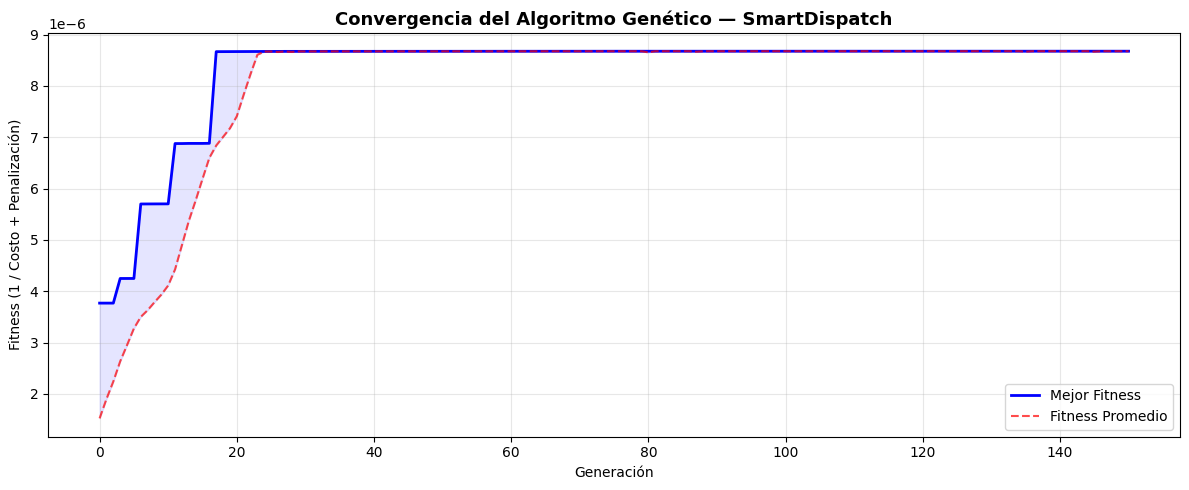

In [ ]:
# EJECUCIÓN Y CONVERGENCIA

GENERACIONES = 150
POBLACION = 200
PROB_CRUCE = 0.8
PROB_MUTACION = 0.15

pop = toolbox.population(n=POBLACION)
hof = tools.HallOfFame(1)
stats = tools.Statistics(lambda ind: ind.fitness.values)
stats.register("max", np.max)
stats.register("avg", np.mean)

logger.info(f"Iniciando AG: {GENERACIONES} generaciones, {POBLACION} individuos.")

pop, logbook = algorithms.eaMuPlusLambda(
    pop, toolbox,
    mu=POBLACION,
    lambda_=POBLACION,
    cxpb=PROB_CRUCE,
    mutpb=PROB_MUTACION,
    ngen=GENERACIONES,
    stats=stats,
    halloffame=hof,
    verbose=False
)

logger.info(f"AG finalizado. Mejor fitness: {hof[0].fitness.values[0]:.6f}")

# ── Gráfico de Convergencia ────────────────────────────────────────────────
gen = logbook.select("gen")
max_fit = logbook.select("max")
avg_fit = logbook.select("avg")

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(gen, max_fit, "b-", label="Mejor Fitness", linewidth=2)
ax.plot(gen, avg_fit, "r--", label="Fitness Promedio", linewidth=1.5, alpha=0.7)
ax.set_title("Convergencia del Algoritmo Genético — SmartDispatch", fontsize=13, fontweight="bold")
ax.set_xlabel("Generación")
ax.set_ylabel("Fitness (1 / Costo + Penalización)")
ax.legend()
ax.grid(True, alpha=0.3)
ax.fill_between(gen, avg_fit, max_fit, alpha=0.1, color="blue")
plt.tight_layout()
plt.savefig("convergencia.png", dpi=150)
plt.show()

**Solución Final y Auditoría del Sistema Experto**

Toma el mejor individuo encontrado por el AG (`hof[0]`, el Hall of Fame) y lo decodifica en rutas concretas.

Para cada camión, muestra:
- Los pedidos asignados y los materiales que transporta.
- El peso total cargado.
- El veredicto de compliance (✅ Aprobado o ⚠️ con infracciones, listando cada regla disparada).
- Para el primer camión, además se imprime el **informe de auditoría completo** generado por `SE.generar_informe()`, como demostración de explicabilidad.

Esta es la salida final que vería el Director de Logística: la ruta óptima junto con la justificación de por qué es segura.

In [ ]:
# SOLUCIÓN FINAL + AUDITORÍA DEL SE

mejor_individuo = hof[0]
rutas_optimas = decodificar(mejor_individuo)

print("\n" + "🏆 SOLUCIÓN OPTIMIZADA — SmartDispatch".center(60))
print("=" * 60)

for i, ruta in enumerate(rutas_optimas):
    camion = Camion(id=f"Camion_{i+1}")
    pedidos_ruta = [PEDIDOS[idx] for idx in ruta]
    pen, infracciones = SE.evaluar(pedidos_ruta, camion)

    print(f"\n🚛 {camion.id}")
    print(f"   Pedidos: {[p.id for p in pedidos_ruta]}")
    print(f"   Materiales: {[p.material.nombre for p in pedidos_ruta]}")
    print(f"   Peso total: {sum(p.material.peso_kg for p in pedidos_ruta):.0f} kg")

    if not infracciones:
        print("   ✅ Compliance: APROBADO (0 infracciones)")
    else:
        print(f"   ⚠️ Infracciones: {len(infracciones)}")
        for inf in infracciones:
            print(f"      • Regla #{inf.regla_id}: {inf.descripcion}")

    # Informe completo del SE para el primer camión (demo de explicabilidad)
    if i == 0:
        print(SE.generar_informe(pedidos_ruta, camion))


           🏆 SOLUCIÓN OPTIMIZADA — SmartDispatch            

🚛 Camion_1
   Pedidos: ['P05']
   Materiales: ['Aditivo Químico']
   Peso total: 575 kg
   ⚠️ Infracciones: 1
      • Regla #2: 🌡️ P05: Aditivo Químico requiere clima controlado

  INFORME DE AUDITORÍA — Camion_1
  Pedidos: ['P05']
  Peso total: 575 kg
  Penalización Sistema Experto: $15,000
  ────────────────────────────────────────────────────────
  [🔴 CRÍTICO] Regla #2: 🌡️ P05: Aditivo Químico requiere clima controlado
           Penalización: $15,000


🚛 Camion_2
   Pedidos: ['P04', 'P01', 'P19']
   Materiales: ['Aditivo Químico', 'Cemento', 'Aditivo Químico']
   Peso total: 2427 kg
   ⚠️ Infracciones: 2
      • Regla #2: 🌡️ P04: Aditivo Químico requiere clima controlado
      • Regla #2: 🌡️ P19: Aditivo Químico requiere clima controlado

🚛 Camion_3
   Pedidos: ['P13', 'P16']
   Materiales: ['Aditivo Químico', 'Aditivo Químico']
   Peso total: 1157 kg
   ⚠️ Infracciones: 2
      • Regla #2: 🌡️ P13: Aditivo Químico requi

**Panel de Parámetros Manuales**

Esta celda permite correr todo el sistema (dataset + AG + auditoría del SE) cambiando los parámetros directamente en el código, sin tocar las celdas anteriores. Editá los valores de la sección "INPUTS DEL USUARIO" y volvé a ejecutar la celda.

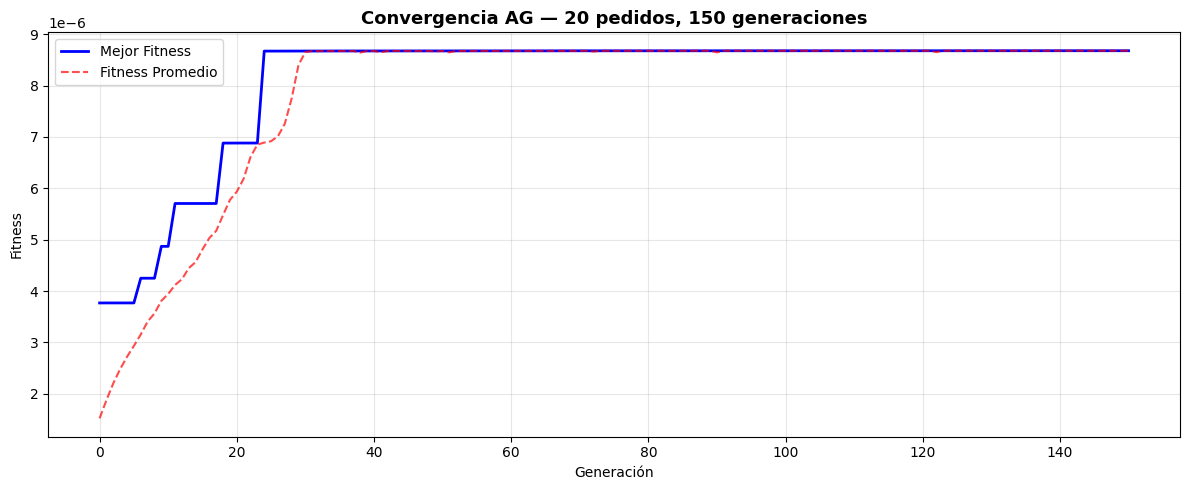


        🏆 SOLUCIÓN OPTIMIZADA (PARÁMETROS MANUALES)         

🚛 Camion_1
   Pedidos: ['P09', 'P12', 'P08', 'P14', 'P02', 'P07', 'P10', 'P06', 'P17']
   Materiales: ['Madera', 'Material Húmedo', 'Acero', 'Madera', 'Madera', 'Material Húmedo', 'Material Húmedo', 'Acero', 'Material Húmedo']
   Peso total: 17784 kg
   Distancia ruta: 103.6 km
   ⚠️ Infracciones: 1
      • Regla #21: 📋 P17: Proveedor sin certificación ISO/FSC

🚛 Camion_2
   Pedidos: ['P20', 'P13', 'P16']
   Materiales: ['Aditivo Químico', 'Aditivo Químico', 'Aditivo Químico']
   Peso total: 1647 kg
   Distancia ruta: 54.9 km
   ⚠️ Infracciones: 3
      • Regla #2: 🌡️ P20: Aditivo Químico requiere clima controlado
      • Regla #2: 🌡️ P13: Aditivo Químico requiere clima controlado
      • Regla #2: 🌡️ P16: Aditivo Químico requiere clima controlado

🚛 Camion_3
   Pedidos: ['P01', 'P19', 'P04']
   Materiales: ['Cemento', 'Aditivo Químico', 'Aditivo Químico']
   Peso total: 2427 kg
   Distancia ruta: 27.5 km
   ⚠️ Infracciones

In [ ]:
# EJECUCIÓN CON PARÁMETROS MANUALES


# ────────────────────────────────────────────────────────────
# INPUTS DEL USUARIO — Editar estos valores manualmente
# ────────────────────────────────────────────────────────────
#
# N_PEDIDOS_MANUAL      → Cantidad de pedidos a generar en el dataset.
#                         Rango sugerido: 10 a 60. Más pedidos = problema
#                         más difícil y más lento de optimizar.
#
# N_CAMIONES_MAX_MANUAL → Cantidad máxima de camiones disponibles para
#                         repartir los pedidos. Rango sugerido: 2 a 8.
#                         Si es muy bajo respecto a N_PEDIDOS_MANUAL, el AG
#                         puede no encontrar una solución sin exceso de peso.
#
# GENERACIONES_MANUAL   → Cuántas iteraciones evolutivas corre el AG.
#                         Rango sugerido: 50 a 300. Más generaciones =
#                         mejor convergencia, pero más tiempo de ejecución.
#
# POBLACION_MANUAL      → Cantidad de individuos (soluciones candidatas)
#                         en cada generación. Rango sugerido: 50 a 400.
#                         Poblaciones grandes exploran más pero son más lentas.
#
# PROB_CRUCE_MANUAL     → Probabilidad de que dos individuos se cruquen
#                         (valor entre 0.0 y 1.0). Valores típicos: 0.6 a 0.9.
#
# PROB_MUTACION_MANUAL  → Probabilidad de mutación por individuo
#                         (valor entre 0.0 y 1.0). Valores típicos: 0.05 a 0.3.
#                         Muy alto = el AG no converge (demasiado ruido).
#                         Muy bajo = el AG puede quedar atrapado en óptimos locales.
#
# SEMILLA_MANUAL        → Número entero para fijar la aleatoriedad y poder
#                         reproducir el mismo resultado. Cambiarla genera
#                         un dataset y una evolución distintos.
#
# ────────────────────────────────────────────────────────────

N_PEDIDOS_MANUAL = 20
N_CAMIONES_MAX_MANUAL = 5
GENERACIONES_MANUAL = 150
POBLACION_MANUAL = 200
PROB_CRUCE_MANUAL = 0.8
PROB_MUTACION_MANUAL = 0.15
SEMILLA_MANUAL = 42

# ────────────────────────────────────────────────────────────
# ────────────────────────────────────────────────────────────

logger.info("="*60)
logger.info("EJECUTANDO SMARTDISPATCH CON PARÁMETROS MANUALES")
logger.info(f"Pedidos={N_PEDIDOS_MANUAL} | Camiones_max={N_CAMIONES_MAX_MANUAL} | "
            f"Generaciones={GENERACIONES_MANUAL} | Poblacion={POBLACION_MANUAL} | "
            f"P_cruce={PROB_CRUCE_MANUAL} | P_mutacion={PROB_MUTACION_MANUAL} | "
            f"Semilla={SEMILLA_MANUAL}")

# ── 1. Regenerar el dataset con el tamaño elegido ──────────────────────────
random.seed(SEMILLA_MANUAL)
np.random.seed(SEMILLA_MANUAL)

OBRAS_M = [
    {"nombre": f"Obra_{i}", "lat": CORRALON["lat"] + random.uniform(-0.15, 0.15),
     "lon": CORRALON["lon"] + random.uniform(-0.15, 0.15)}
    for i in range(1, N_PEDIDOS_MANUAL + 1)
]

def generar_pedidos_manual(n):
    pedidos = []
    for i in range(n):
        obra = random.choice(OBRAS_M)
        mat_data = random.choice(TIPOS_MATERIALES)
        material = Material(
            nombre=mat_data["nombre"],
            peso_kg=mat_data["peso_base"] + random.uniform(-200, 200),
            volumen_m3=mat_data["vol_base"] + random.uniform(-0.2, 0.2),
            requiere_clima_controlado=mat_data["clima"],
            es_peligroso=mat_data["peligroso"],
        )
        inicio = random.choice([480, 540, 600])
        pedidos.append(Pedido(
            id=f"P{i+1:02d}",
            material=material,
            obra_destino=obra["nombre"],
            coordenadas=(obra["lat"], obra["lon"]),
            ventana_inicio=inicio,
            ventana_fin=inicio + 120,
            proveedor_certificado=random.random() > 0.1,
        ))
    return pedidos

PEDIDOS_M = generar_pedidos_manual(N_PEDIDOS_MANUAL)
logger.info(f"Dataset manual generado: {len(PEDIDOS_M)} pedidos.")

# ── 2. Reconfigurar el AG con los nuevos parámetros ─────────────────────────
N_PEDIDOS_M = len(PEDIDOS_M)
DELIMITADOR_M = N_PEDIDOS_M
corralon_coords_m = (CORRALON["lat"], CORRALON["lon"])

def decodificar_m(individuo):
    rutas, ruta_actual = [], []
    for gen in individuo:
        if gen == DELIMITADOR_M:
            if ruta_actual:
                rutas.append(ruta_actual)
                ruta_actual = []
        else:
            ruta_actual.append(gen)
    if ruta_actual:
        rutas.append(ruta_actual)
    return [r for r in rutas if r]

def reparar_m(individuo):
    presentes, duplicados_idx = set(), []
    for i, gen in enumerate(individuo):
        if gen != DELIMITADOR_M:
            if gen in presentes:
                duplicados_idx.append(i)
            else:
                presentes.add(gen)
    faltantes = list(set(range(N_PEDIDOS_M)) - presentes)
    for idx_dup, faltante in zip(duplicados_idx, faltantes):
        individuo[idx_dup] = faltante
    faltantes = list(set(range(N_PEDIDOS_M)) - set(g for g in individuo if g != DELIMITADOR_M))
    for i in range(len(individuo)):
        if not faltantes:
            break
        if individuo[i] == DELIMITADOR_M and faltantes:
            individuo[i] = faltantes.pop()
    return individuo

def fitness_hibrido_m(individuo):
    rutas = decodificar_m(individuo)
    costo_total, pen_total = 0.0, 0.0
    for i, ruta in enumerate(rutas):
        camion = Camion(id=f"Camion_{i+1}")
        pedidos_ruta = [PEDIDOS_M[idx] for idx in ruta]
        ruta_completa = [corralon_coords_m] + [p.coordenadas for p in pedidos_ruta] + [corralon_coords_m]
        for j in range(len(ruta_completa) - 1):
            costo_total += distancia_km(ruta_completa[j], ruta_completa[j+1])
        pen, _ = SE.evaluar(pedidos_ruta, camion)
        pen_total += pen
    return (1.0 / (costo_total + pen_total + 1e-6),)

def mate_y_reparar_m(ind1, ind2):
    tools.cxUniform(ind1, ind2, indpb=0.5)
    reparar_m(ind1)
    reparar_m(ind2)
    return ind1, ind2

def mutar_y_reparar_m(individuo, indpb):
    tools.mutShuffleIndexes(individuo, indpb=indpb)
    reparar_m(individuo)
    return individuo,

def crear_individuo_m():
    idx = list(range(N_PEDIDOS_M))
    random.shuffle(idx)
    n_sep = random.randint(1, N_CAMIONES_MAX_MANUAL - 1)
    posiciones = sorted(random.sample(range(1, N_PEDIDOS_M), min(n_sep, N_PEDIDOS_M - 1)))
    individuo, prev = [], 0
    for pos in posiciones:
        individuo.extend(idx[prev:pos])
        individuo.append(DELIMITADOR_M)
        prev = pos
    individuo.extend(idx[prev:])
    return creator.Individuo(individuo)

toolbox_m = base.Toolbox()
toolbox_m.register("individual", crear_individuo_m)
toolbox_m.register("population", tools.initRepeat, list, toolbox_m.individual)
toolbox_m.register("evaluate", fitness_hibrido_m)
toolbox_m.register("select", tools.selTournament, tournsize=3)
toolbox_m.register("mate", mate_y_reparar_m)
toolbox_m.register("mutate", mutar_y_reparar_m, indpb=PROB_MUTACION_MANUAL)

# ── 3. Ejecutar el AG ────────────────────────────────────────────────────
pop_m = toolbox_m.population(n=POBLACION_MANUAL)
hof_m = tools.HallOfFame(1)
stats_m = tools.Statistics(lambda ind: ind.fitness.values)
stats_m.register("max", np.max)
stats_m.register("avg", np.mean)

logger.info("Ejecutando AG con parámetros manuales...")

pop_m, logbook_m = algorithms.eaMuPlusLambda(
    pop_m, toolbox_m,
    mu=POBLACION_MANUAL,
    lambda_=POBLACION_MANUAL,
    cxpb=PROB_CRUCE_MANUAL,
    mutpb=PROB_MUTACION_MANUAL,
    ngen=GENERACIONES_MANUAL,
    stats=stats_m,
    halloffame=hof_m,
    verbose=False
)

logger.info(f"AG manual finalizado. Mejor fitness: {hof_m[0].fitness.values[0]:.6f}")

# ── 4. Gráfico de convergencia ───────────────────────────────────────────
gen_m = logbook_m.select("gen")
max_fit_m = logbook_m.select("max")
avg_fit_m = logbook_m.select("avg")

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(gen_m, max_fit_m, "b-", label="Mejor Fitness", linewidth=2)
ax.plot(gen_m, avg_fit_m, "r--", label="Fitness Promedio", linewidth=1.5, alpha=0.7)
ax.set_title(f"Convergencia AG — {N_PEDIDOS_MANUAL} pedidos, {GENERACIONES_MANUAL} generaciones", fontsize=13, fontweight="bold")
ax.set_xlabel("Generación")
ax.set_ylabel("Fitness")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ── 5. Solución final y auditoría ────────────────────────────────────────
mejor_individuo_m = hof_m[0]
rutas_optimas_m = decodificar_m(mejor_individuo_m)

print("\n" + "🏆 SOLUCIÓN OPTIMIZADA (PARÁMETROS MANUALES)".center(60))
print("=" * 60)

total_pen_m = 0
total_dist_m = 0

for i, ruta in enumerate(rutas_optimas_m):
    camion = Camion(id=f"Camion_{i+1}")
    pedidos_ruta = [PEDIDOS_M[idx] for idx in ruta]
    pen, infracciones = SE.evaluar(pedidos_ruta, camion)
    total_pen_m += pen

    ruta_completa = [corralon_coords_m] + [p.coordenadas for p in pedidos_ruta] + [corralon_coords_m]
    dist_camion = sum(distancia_km(ruta_completa[j], ruta_completa[j+1]) for j in range(len(ruta_completa)-1))
    total_dist_m += dist_camion

    print(f"\n🚛 {camion.id}")
    print(f"   Pedidos: {[p.id for p in pedidos_ruta]}")
    print(f"   Materiales: {[p.material.nombre for p in pedidos_ruta]}")
    print(f"   Peso total: {sum(p.material.peso_kg for p in pedidos_ruta):.0f} kg")
    print(f"   Distancia ruta: {dist_camion:.1f} km")

    if not infracciones:
        print("   ✅ Compliance: APROBADO (0 infracciones)")
    else:
        print(f"   ⚠️ Infracciones: {len(infracciones)}")
        for inf in infracciones:
            print(f"      • Regla #{inf.regla_id}: {inf.descripcion}")

print("\n" + "─"*60)
print(f"📊 RESUMEN GLOBAL")
print(f"   Camiones utilizados:     {len(rutas_optimas_m)}")
print(f"   Distancia total:         {total_dist_m:.1f} km")
print(f"   Penalización SE total:   ${total_pen_m:,.0f}")
print(f"   Fitness final:           {hof_m[0].fitness.values[0]:.6f}")
print(f"   Estado:                  {'✅ 100% COMPLIANT' if total_pen_m == 0 else '⚠️ CON INFRACCIONES PENDIENTES'}")
print("─"*60)

## **App Demo**

https://smartdispatch-czgxdrvx6ifwnb8svruz3j.streamlit.app/